# ML Foundations — Notebook 1: Math from First Principles
## Build Fellowship Machine Vision Course

This notebook has no PyTorch and no black boxes.  
Every idea is built from a picture first, then a formula, then working code.

By the end you will understand **exactly** what happens when a neural network "learns" —
because you will have derived the mechanism yourself.

---

### What we cover

| Section | Topic |
|---------|-------|
| 0 | Setup & shared utilities |
| 1 | Functions as machines — parameterised models |
| 2 | The error surface — what "fitting" means geometrically |
| 3 | Limits and the derivative — rise over run to first principles |
| 4 | Rules of differentiation — power, product, chain |
| 5 | Partial derivatives and gradients |
| 6 | The gradient as a compass — which direction is downhill? |
| 7 | Gradient descent — the full algorithm, step by step |
| 8 | Learning rate — too small, too large, just right |
| 9 | The chain rule in depth — composing derivatives |
| 10 | Gradient descent on a non-convex surface — local minima & saddle points |
| 11 | From scalars to vectors — matrix calculus preview |
| 12 | Putting it all together — fitting a curve end-to-end |

> **How to read this notebook:** every code cell that starts with  
> `# 🔍 DERIVATION` works through math step by step.  
> Cells starting with `# 🖼 PLOT` produce the figure discussed above them.  
> Cells starting with `# ⚙ IMPLEMENTATION` are the working algorithm.


---
## Section 0 — Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Shared style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'lines.linewidth': 2.2,
})

C = {                          # colour palette used throughout
    'blue':   '#1565C0',
    'red':    '#C62828',
    'orange': '#E65100',
    'green':  '#2E7D32',
    'purple': '#6A1B9A',
    'grey':   '#546E7A',
    'light':  '#ECEFF1',
}

def vline(ax, x, color=C['grey'], ls='--', lw=1.2, alpha=0.7):
    ax.axvline(x, color=color, ls=ls, lw=lw, alpha=alpha)

def hline(ax, y, color=C['grey'], ls='--', lw=1.2, alpha=0.7):
    ax.axhline(y, color=color, ls=ls, lw=lw, alpha=alpha)

print("✓ Setup complete")


✓ Setup complete


---
## Section 1 — Functions as Machines

A **model** is a parameterised function: it takes an input $x$ and produces an output
$\hat{y}$, controlled by parameters $\theta$.

$$\hat{y} = f(x;\, \theta)$$

**Training** is the process of choosing $\theta$ so that $\hat{y}$ is close to
the true target $y$.

The simplest model is a straight line:

$$\hat{y} = w \cdot x + b \qquad \theta = (w, b)$$

$w$ is the **weight** (slope) and $b$ is the **bias** (intercept).  
These are exactly the same $w$ and $b$ you will see in every layer of a neural network.


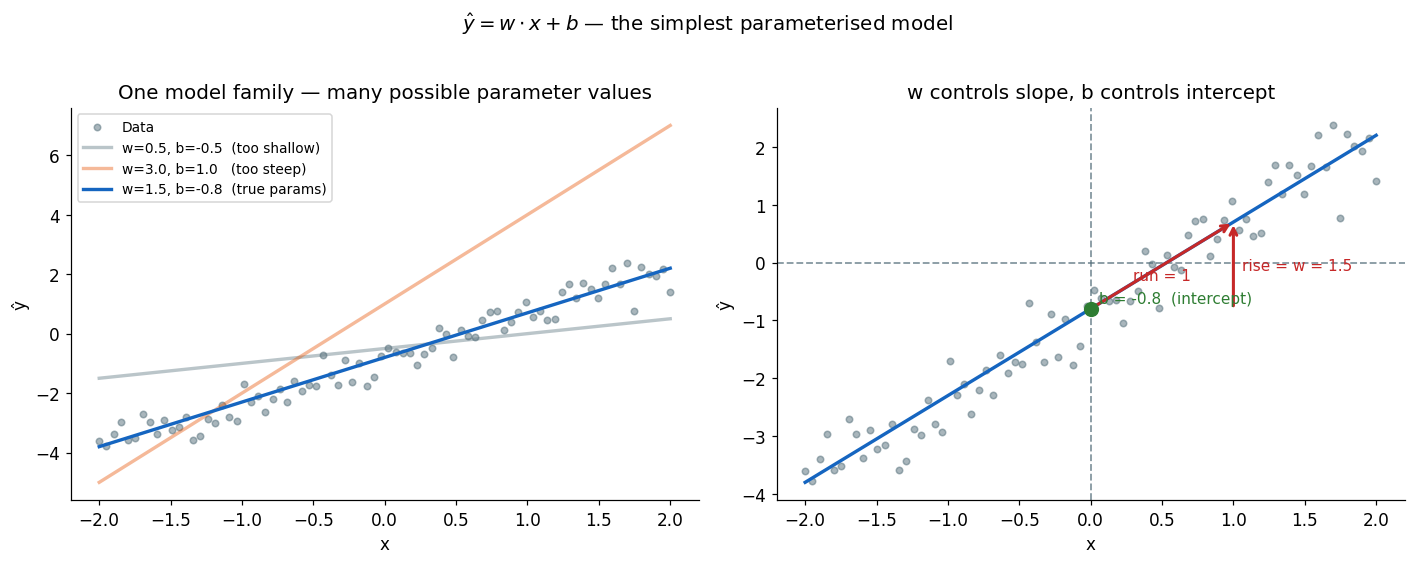

In [2]:
# 🖼 PLOT — Parameterised function family
# Different (w, b) pairs are different members of the same model family.

np.random.seed(SEED)
x_true = np.linspace(-2, 2, 80)
y_true = 1.5 * x_true - 0.8 + np.random.randn(80) * 0.4   # ground truth + noise

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: the family of lines
ax = axes[0]
candidates = [
    (0.5, -0.5, C['grey'],   0.4, 'w=0.5, b=-0.5  (too shallow)'),
    (3.0,  1.0, C['orange'], 0.4, 'w=3.0, b=1.0   (too steep)'),
    (1.5, -0.8, C['blue'],   1.0, 'w=1.5, b=-0.8  (true params)'),
]
ax.scatter(x_true, y_true, s=18, color=C['grey'], alpha=0.5, label='Data')
for w, b, col, alpha, lbl in candidates:
    ax.plot(x_true, w*x_true + b, color=col, alpha=alpha, label=lbl)
ax.set_xlabel('x');  ax.set_ylabel('ŷ')
ax.set_title('One model family — many possible parameter values')
ax.legend(fontsize=9)

# Right: annotate what w and b do geometrically
ax = axes[1]
ax.scatter(x_true, y_true, s=18, color=C['grey'], alpha=0.5)
w_ex, b_ex = 1.5, -0.8
x_ann = np.array([-2, 2])
ax.plot(x_ann, w_ex*x_ann + b_ex, color=C['blue'])

# Slope triangle
x1, x2 = 0.0, 1.0
ax.annotate('', xy=(x2, w_ex*x2+b_ex), xytext=(x1, w_ex*x1+b_ex),
            arrowprops=dict(arrowstyle='->', color=C['red'], lw=2))
ax.annotate('', xy=(x2, w_ex*x2+b_ex), xytext=(x2, w_ex*x1+b_ex),
            arrowprops=dict(arrowstyle='->', color=C['red'], lw=2))
ax.text(0.5,  w_ex*0.5+b_ex - 0.25, 'run = 1', ha='center', color=C['red'], fontsize=10)
ax.text(x2 + 0.06, w_ex*x1+b_ex + w_ex/2, f'rise = w = {w_ex}',
        color=C['red'], fontsize=10, va='center')

# Intercept
ax.scatter([0], [b_ex], s=80, zorder=5, color=C['green'])
ax.text(0.06, b_ex + 0.1, f'b = {b_ex}  (intercept)', color=C['green'], fontsize=10)

ax.set_xlabel('x');  ax.set_ylabel('ŷ')
ax.set_title('w controls slope, b controls intercept')
hline(ax, 0)
vline(ax, 0)

plt.suptitle(r'$\hat{y} = w \cdot x + b$ — the simplest parameterised model',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## Section 2 — The Error Surface: What "Fitting" Means Geometrically

To measure how wrong our parameters are, we need a **loss function** $\mathcal{L}(w, b)$.

For a linear model with Mean Squared Error:

$$\mathcal{L}(w, b) = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2
= \frac{1}{N} \sum_{i=1}^{N} (w x_i + b - y_i)^2$$

This loss is a **surface** in $(w, b)$ space.  
Training = finding the **lowest point** on this surface.

For a linear model with MSE, this surface is a **bowl** (convex quadratic).  
Neural networks have much more complex surfaces — but the same idea applies.


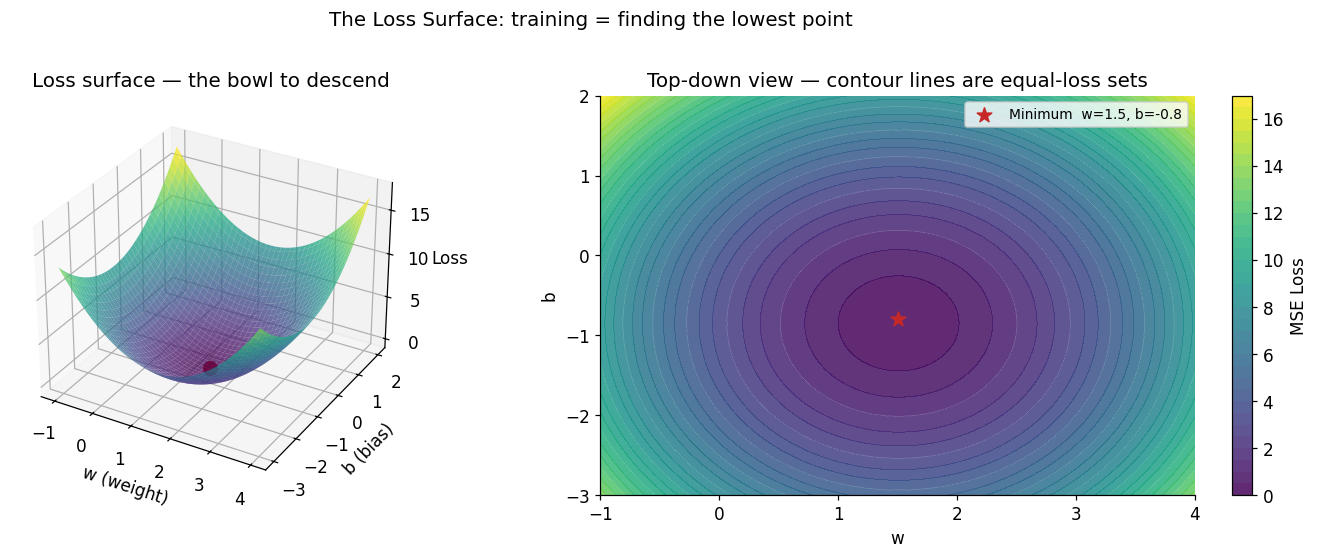

Loss at true parameters (w=1.5, b=-0.8): 0.1473
Loss at bad parameters  (w=3.0,  b=1.0 ):  6.6028


In [3]:
# 🖼 PLOT — The loss surface as a 3D bowl and 2D contour map

def mse_loss(w, b, x, y):
    y_hat = w * x + b
    return np.mean((y_hat - y)**2)

# Grid over (w, b) space
w_range = np.linspace(-1, 4, 80)
b_range = np.linspace(-3, 2, 80)
W, B    = np.meshgrid(w_range, b_range)
Loss    = np.array([[mse_loss(w, b, x_true, y_true)
                     for w in w_range] for b in b_range])

w_star, b_star = 1.5, -0.8   # true parameters

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig)

# ── 3D surface ────────────────────────────────────────────────────────────────
ax3d = fig.add_subplot(gs[0], projection='3d')
ax3d.plot_surface(W, B, Loss, cmap='viridis', alpha=0.75, linewidth=0)
ax3d.scatter([w_star], [b_star], [mse_loss(w_star, b_star, x_true, y_true)],
             color=C['red'], s=80, zorder=5, label='Minimum')
ax3d.set_xlabel('w (weight)');  ax3d.set_ylabel('b (bias)')
ax3d.set_zlabel('Loss')
ax3d.set_title('Loss surface — the bowl to descend')
ax3d.view_init(elev=30, azim=-60)

# ── 2D contour ────────────────────────────────────────────────────────────────
ax2d = fig.add_subplot(gs[1])
cf   = ax2d.contourf(W, B, Loss, levels=40, cmap='viridis', alpha=0.85)
ax2d.contour(W, B, Loss, levels=15, colors='white', linewidths=0.4, alpha=0.4)
ax2d.scatter([w_star], [b_star], color=C['red'], s=100, zorder=5,
             label=f'Minimum  w={w_star}, b={b_star}', marker='*')
plt.colorbar(cf, ax=ax2d, label='MSE Loss')
ax2d.set_xlabel('w');  ax2d.set_ylabel('b')
ax2d.set_title('Top-down view — contour lines are equal-loss sets')
ax2d.legend(fontsize=9)

plt.suptitle('The Loss Surface: training = finding the lowest point', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Loss at true parameters (w={w_star}, b={b_star}): "
      f"{mse_loss(w_star, b_star, x_true, y_true):.4f}")
print(f"Loss at bad parameters  (w=3.0,  b=1.0 ):  "
      f"{mse_loss(3.0, 1.0, x_true, y_true):.4f}")


---
## Section 3 — Limits and the Derivative: Rise Over Run to First Principles

The derivative answers one question: **how fast is the function changing right here?**

### The finite difference approximation

Pick two points on a curve, draw a line through them (secant line).  
As the two points get closer, the secant line approaches the **tangent line**.  
The slope of that tangent line is the derivative.

$$f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}$$

This limit is the foundation of all of calculus.  
Every gradient your GPU computes is a high-dimensional version of this formula.

### Computing the derivative of $f(x) = x^2$ from the definition

$$\frac{d}{dx}x^2 = \lim_{h \to 0} \frac{(x+h)^2 - x^2}{h}
= \lim_{h \to 0} \frac{x^2 + 2xh + h^2 - x^2}{h}
= \lim_{h \to 0} \frac{2xh + h^2}{h}
= \lim_{h \to 0} (2x + h) = 2x$$


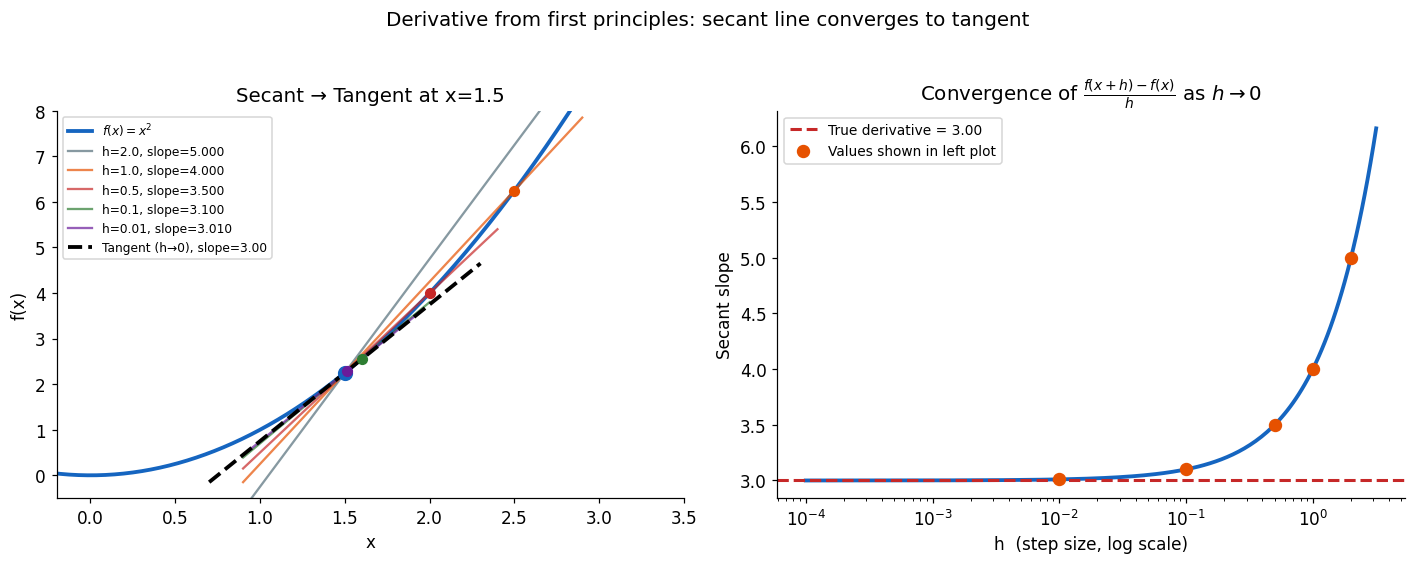

In [4]:
# 🔍 DERIVATION — Secant line converging to tangent

def f(x): return x**2          # our test function
def f_prime(x): return 2*x     # analytical derivative

x0    = 1.5                    # point of interest
h_vals = [2.0, 1.0, 0.5, 0.1, 0.01]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: secant lines converging to tangent
ax = axes[0]
x_plot = np.linspace(-0.5, 3.5, 300)
ax.plot(x_plot, f(x_plot), color=C['blue'], lw=2.5, label=r'$f(x) = x^2$')
ax.scatter([x0], [f(x0)], s=80, color=C['blue'], zorder=5)

colors_h = [C['grey'], C['orange'], C['red'], C['green'], C['purple']]
for h, col in zip(h_vals, colors_h):
    slope  = (f(x0 + h) - f(x0)) / h
    x_line = np.linspace(x0 - 0.6, x0 + h + 0.4, 50)
    y_line = f(x0) + slope * (x_line - x0)
    ax.plot(x_line, y_line, color=col, alpha=0.7, lw=1.5, label=f'h={h}, slope={slope:.3f}')
    ax.scatter([x0 + h], [f(x0 + h)], s=40, color=col, zorder=5)

# True tangent
slope_true = f_prime(x0)
x_tan = np.linspace(x0 - 0.8, x0 + 0.8, 50)
ax.plot(x_tan, f(x0) + slope_true*(x_tan - x0),
        color='black', lw=2.5, ls='--', label=f'Tangent (h→0), slope={slope_true:.2f}')
ax.set_xlim(-0.2, 3.5); ax.set_ylim(-0.5, 8)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(f'Secant → Tangent at x={x0}')
ax.legend(fontsize=8)

# Right: slope of secant vs h  (convergence plot)
ax = axes[1]
h_fine  = np.logspace(-4, 0.5, 200)
slopes  = [(f(x0 + h) - f(x0)) / h for h in h_fine]
ax.semilogx(h_fine, slopes, color=C['blue'], lw=2.5)
ax.axhline(f_prime(x0), color=C['red'], ls='--', lw=2,
           label=f"True derivative = {f_prime(x0):.2f}")
ax.scatter(h_vals, [(f(x0+h)-f(x0))/h for h in h_vals],
           s=60, color=C['orange'], zorder=5, label='Values shown in left plot')
ax.set_xlabel('h  (step size, log scale)')
ax.set_ylabel('Secant slope')
ax.set_title(r'Convergence of $\frac{f(x+h)-f(x)}{h}$ as $h \to 0$')
ax.legend(fontsize=9)

plt.suptitle("Derivative from first principles: secant line converges to tangent",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [5]:
# 🔍 DERIVATION — Numerical vs analytical derivatives for several functions

def numerical_deriv(f, x, h=1e-5):
    """Central difference — more accurate than forward difference."""
    return (f(x + h) - f(x - h)) / (2 * h)

functions = {
    r'$x^2$':          (lambda x: x**2,          lambda x: 2*x),
    r'$x^3$':          (lambda x: x**3,           lambda x: 3*x**2),
    r'$\sin(x)$':     (lambda x: np.sin(x),      lambda x: np.cos(x)),
    r'$e^x$':          (lambda x: np.exp(x),      lambda x: np.exp(x)),
    r'$\ln(x)$':      (lambda x: np.log(x),      lambda x: 1/x),
}

x_test = np.array([0.5, 1.0, 1.5, 2.0])

print(f"{'Function':<14}  {'x':>5}  {'Numerical':>12}  {'Analytical':>12}  {'Error':>12}")
print("-" * 62)
for name, (fn, dfn) in functions.items():
    for x in x_test:
        try:
            num = numerical_deriv(fn, x)
            ana = dfn(x)
            err = abs(num - ana)
            fname = name.replace('$','').replace('\\','')
            print(f"  {fname:<12}  {x:>5.1f}  {num:>12.7f}  {ana:>12.7f}  {err:>12.2e}")
        except Exception:
            pass
    print()

print("Central difference error is O(h²) ≈ 1e-10 — essentially exact for our purposes.")


Function            x     Numerical    Analytical         Error
--------------------------------------------------------------
  x^2             0.5     1.0000000     1.0000000      1.78e-12
  x^2             1.0     2.0000000     2.0000000      2.00e-12
  x^2             1.5     3.0000000     3.0000000      1.97e-11
  x^2             2.0     4.0000000     4.0000000      2.62e-11

  x^3             0.5     0.7500000     0.7500000      9.93e-11
  x^3             1.0     3.0000000     3.0000000      9.74e-11
  x^3             1.5     6.7500000     6.7500000      1.44e-10
  x^3             2.0    12.0000000    12.0000000      2.12e-10

  sin(x)          0.5     0.8775826     0.8775826      1.75e-11
  sin(x)          1.0     0.5403023     0.5403023      1.11e-11
  sin(x)          1.5     0.0707372     0.0707372      4.86e-12
  sin(x)          2.0    -0.4161468    -0.4161468      6.69e-12

  e^x             0.5     1.6487213     1.6487213      1.93e-11
  e^x             1.0     2.7182818   

---
## Section 4 — Rules of Differentiation

We don't recompute from the limit every time.  
Instead, we have four rules that cover almost everything we'll ever need.

### 4.1 Power rule

$$\frac{d}{dx} x^n = n x^{n-1}$$

**Examples:**  
$\frac{d}{dx} x^2 = 2x$, $\quad \frac{d}{dx} x^3 = 3x^2$, $\quad \frac{d}{dx} x^{-1} = -x^{-2}$

### 4.2 Sum / constant rule

$$\frac{d}{dx}[af(x) + bg(x)] = af'(x) + bg'(x)$$

### 4.3 Product rule

$$\frac{d}{dx}[f(x) \cdot g(x)] = f'(x)g(x) + f(x)g'(x)$$

### 4.4 Chain rule — the most important one

If $y = f(g(x))$ — a function of a function — then:

$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}
\qquad \text{where } u = g(x)$$

**Read it as:** "the derivative of the outside, times the derivative of the inside."

This is **exactly** what backpropagation computes — layer by layer, outside in.


RULE VERIFICATION — numerical vs analytical

[Power rule]  d/dx x^4  at x=2
  Analytical  : 4·x³ = 32.0000
  Numerical   : 32.0000

[Sum rule]  d/dx (3x³ + 2x)  at x=2
  Analytical  : 9x² + 2 = 38.0000
  Numerical   : 38.0000

[Product rule]  d/dx [x² · sin(x)]  at x=2
  Analytical  : 2x·sin(x) + x²·cos(x) = 1.9726
  Numerical   : 1.9726

[Chain rule]  d/dx [sin(x)²]  at x=2
  u = sin(x),  f(u) = u²
  dy/du = 2u,   du/dx = cos(x)
  dy/dx = 2·sin(x)·cos(x) = -0.7568
  Numerical: -0.7568


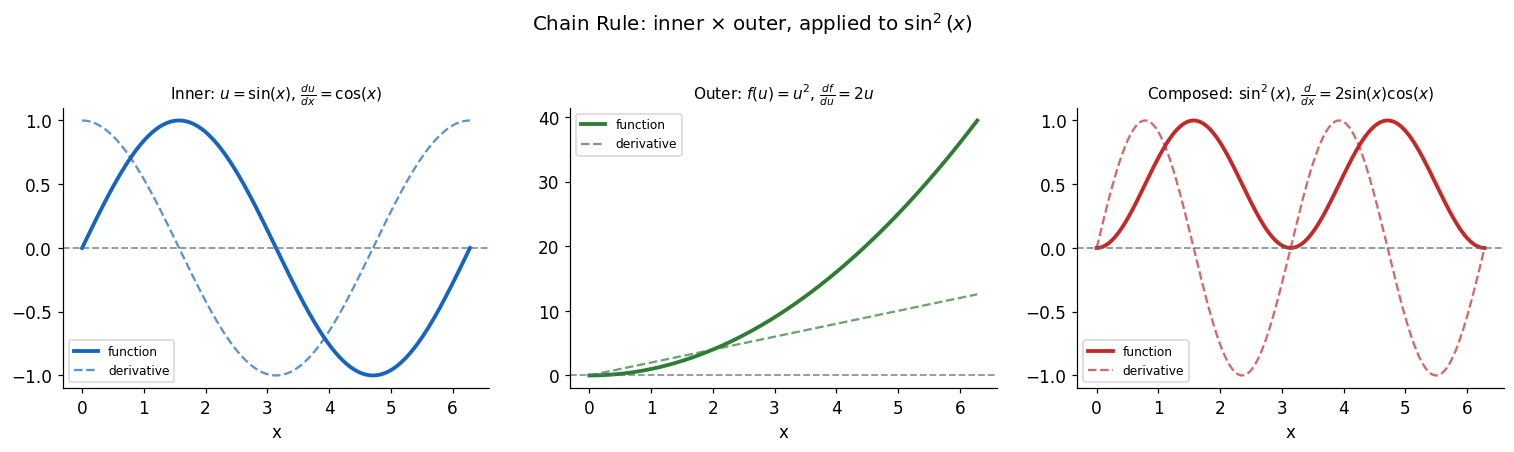

In [6]:
# 🔍 DERIVATION — Verifying all four rules numerically

print("=" * 65)
print("RULE VERIFICATION — numerical vs analytical")
print("=" * 65)

x_v = 2.0

# ── Power rule ────────────────────────────────────────────────────────────────
print("\n[Power rule]  d/dx x^4  at x=2")
print(f"  Analytical  : 4·x³ = {4 * x_v**3:.4f}")
print(f"  Numerical   : {numerical_deriv(lambda x: x**4, x_v):.4f}")

# ── Sum rule ──────────────────────────────────────────────────────────────────
print("\n[Sum rule]  d/dx (3x³ + 2x)  at x=2")
print(f"  Analytical  : 9x² + 2 = {9*x_v**2 + 2:.4f}")
print(f"  Numerical   : {numerical_deriv(lambda x: 3*x**3 + 2*x, x_v):.4f}")

# ── Product rule ──────────────────────────────────────────────────────────────
# f(x)=x², g(x)=sin(x)  →  f'g + fg' = 2x·sin(x) + x²·cos(x)
print("\n[Product rule]  d/dx [x² · sin(x)]  at x=2")
analytical_prod = 2*x_v*np.sin(x_v) + x_v**2*np.cos(x_v)
print(f"  Analytical  : 2x·sin(x) + x²·cos(x) = {analytical_prod:.4f}")
print(f"  Numerical   : {numerical_deriv(lambda x: x**2 * np.sin(x), x_v):.4f}")

# ── Chain rule ────────────────────────────────────────────────────────────────
# f(u) = u², u(x) = sin(x)  →  dy/dx = 2u · cos(x) = 2sin(x)cos(x)
print("\n[Chain rule]  d/dx [sin(x)²]  at x=2")
print("  u = sin(x),  f(u) = u²")
print("  dy/du = 2u,   du/dx = cos(x)")
u        = np.sin(x_v)
dydu     = 2 * u
dudx     = np.cos(x_v)
analytical_chain = dydu * dudx
print(f"  dy/dx = 2·sin(x)·cos(x) = {analytical_chain:.4f}")
print(f"  Numerical: {numerical_deriv(lambda x: np.sin(x)**2, x_v):.4f}")

# ── Visualise chain rule ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x_pl = np.linspace(0, 2*np.pi, 300)

for ax, (fn, dfn, title, color) in zip(axes, [
    (np.sin,          np.cos,
     r'Inner: $u = \sin(x)$, $\frac{du}{dx} = \cos(x)$', C['blue']),
    (lambda x: x**2, lambda x: 2*x,
     r'Outer: $f(u) = u^2$, $\frac{df}{du} = 2u$', C['green']),
    (lambda x: np.sin(x)**2,
     lambda x: 2*np.sin(x)*np.cos(x),
     r'Composed: $\sin^2(x)$, $\frac{d}{dx} = 2\sin(x)\cos(x)$', C['red']),
]):
    ax.plot(x_pl, fn(x_pl),  color=color, lw=2.5, label='function')
    ax.plot(x_pl, dfn(x_pl), color=color, lw=1.5, ls='--', alpha=0.7, label='derivative')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x'); ax.legend(fontsize=8)
    hline(ax, 0)

plt.suptitle('Chain Rule: inner × outer, applied to $\sin^2(x)$', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## Section 5 — Partial Derivatives and Gradients

Our loss $\mathcal{L}(w, b)$ depends on **two** parameters.  
To know how to change each one, we differentiate with respect to each **separately**,
treating the other as a constant.  
This is a **partial derivative**.

$$\frac{\partial \mathcal{L}}{\partial w} = \text{"how much does } \mathcal{L} \text{ change if I nudge } w \text{ a little?"}$$

For $\mathcal{L}(w, b) = \frac{1}{N}\sum_i (wx_i + b - y_i)^2$:

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{2}{N}\sum_i (wx_i + b - y_i)\cdot x_i$$

$$\frac{\partial \mathcal{L}}{\partial b} = \frac{2}{N}\sum_i (wx_i + b - y_i)$$

### The gradient

The **gradient** is a vector that stacks all partial derivatives:

$$\nabla \mathcal{L} = \begin{pmatrix} \frac{\partial \mathcal{L}}{\partial w} \\[4pt] \frac{\partial \mathcal{L}}{\partial b} \end{pmatrix}$$

It points in the direction of **steepest ascent**.  
The negative gradient points in the direction of **steepest descent** — which is where we want to go.


In [7]:
# 🔍 DERIVATION — Analytical gradients for MSE loss on linear model

def mse_grad(w, b, x, y):
    """
    Analytical gradients of MSE loss for ŷ = wx + b.

    Derivation:
      L = (1/N) Σ (wx_i + b - y_i)²
      dL/dw = (2/N) Σ (wx_i + b - y_i) · x_i   [chain rule: outer·inner]
      dL/db = (2/N) Σ (wx_i + b - y_i)           [inner deriv w.r.t. b = 1]
    """
    residuals = (w * x + b) - y          # prediction error
    dL_dw     = 2 * np.mean(residuals * x)
    dL_db     = 2 * np.mean(residuals)
    return dL_dw, dL_db

# Numerical gradient check
def numerical_grad_2d(fn, w, b, h=1e-5):
    """Central difference for a function of two scalars."""
    dw = (fn(w+h, b) - fn(w-h, b)) / (2*h)
    db = (fn(w, b+h) - fn(w, b-h)) / (2*h)
    return dw, db

test_points = [(-1.0, 2.0), (1.5, -0.8), (0.0, 0.0), (3.0, 1.0)]

print(f"{'w':>6} {'b':>6}  {'dL/dw (ana)':>14} {'dL/dw (num)':>14}  "
      f"{'dL/db (ana)':>14} {'dL/db (num)':>14}")
print("-" * 75)
for w_t, b_t in test_points:
    dw_a, db_a = mse_grad(w_t, b_t, x_true, y_true)
    fn2d = lambda w, b: mse_loss(w, b, x_true, y_true)
    dw_n, db_n = numerical_grad_2d(fn2d, w_t, b_t)
    print(f"{w_t:>6.1f} {b_t:>6.1f}  {dw_a:>14.6f} {dw_n:>14.6f}  "
          f"{db_a:>14.6f} {db_n:>14.6f}")

print("\nAnalytical and numerical gradients match to 6 decimal places. ✓")


     w      b     dL/dw (ana)    dL/dw (num)     dL/db (ana)    dL/db (num)
---------------------------------------------------------------------------
  -1.0    2.0       -6.861308      -6.861308        5.699072       5.699072
   1.5   -0.8       -0.025865      -0.025865        0.099072       0.099072
   0.0    0.0       -4.127130      -4.127130        1.699072       1.699072
   3.0    1.0        4.075401       4.075401        3.699072       3.699072

Analytical and numerical gradients match to 6 decimal places. ✓


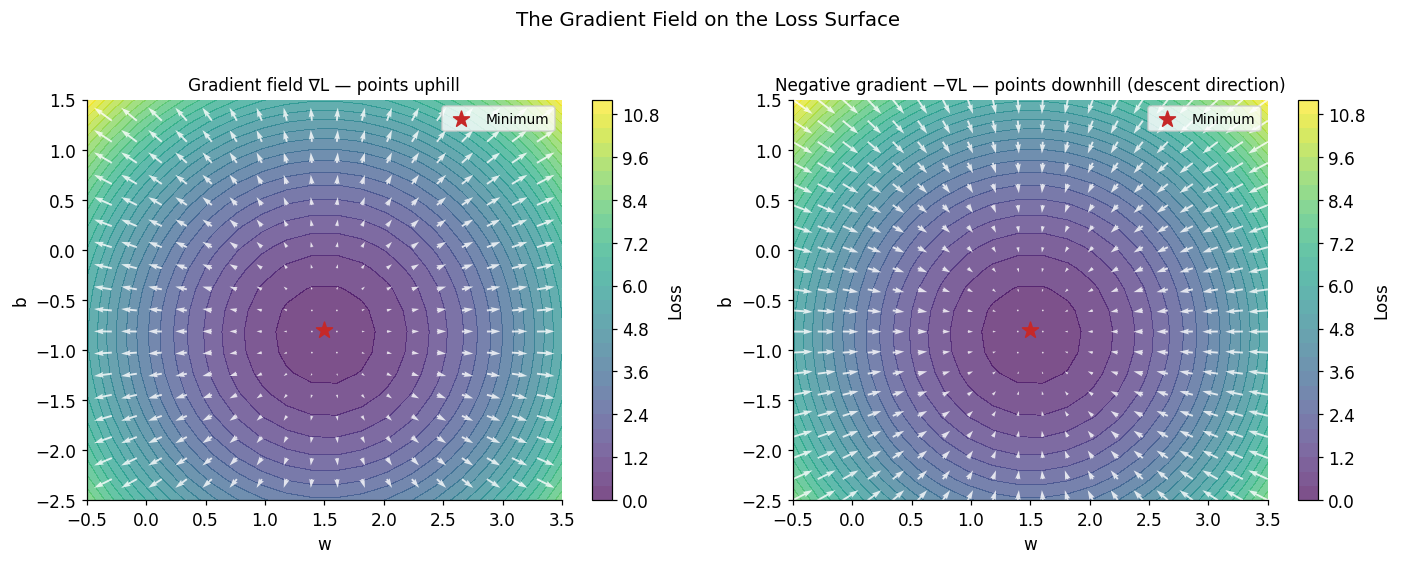

Key insight: the negative gradient at any point is a compass needle
pointing toward the nearest valley — this is how gradient descent navigates.


In [8]:
# 🖼 PLOT — Gradient field on the loss surface

w_range_g = np.linspace(-0.5, 3.5, 20)
b_range_g  = np.linspace(-2.5, 1.5, 20)
W_g, B_g   = np.meshgrid(w_range_g, b_range_g)

# Evaluate gradient at each grid point
DW = np.zeros_like(W_g)
DB = np.zeros_like(B_g)
for i in range(W_g.shape[0]):
    for j in range(W_g.shape[1]):
        DW[i,j], DB[i,j] = mse_grad(W_g[i,j], B_g[i,j], x_true, y_true)

# Loss for contour background
Loss_g = np.array([[mse_loss(w, b, x_true, y_true)
                    for w in w_range_g] for b in b_range_g])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (DW_plot, DB_plot, title, scale) in zip(axes, [
    (DW, DB, 'Gradient field ∇L — points uphill', 1.0),
    (-DW, -DB, 'Negative gradient −∇L — points downhill (descent direction)', 1.0),
]):
    cf = ax.contourf(W_g, B_g, Loss_g, levels=30, cmap='viridis', alpha=0.7)
    ax.quiver(W_g, B_g, DW_plot, DB_plot,
              color='white', alpha=0.8, scale=None, scale_units='xy',
              angles='xy', width=0.004)
    ax.scatter([1.5], [-0.8], color=C['red'], s=120, zorder=6,
               marker='*', label='Minimum')
    ax.set_xlabel('w'); ax.set_ylabel('b')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    plt.colorbar(cf, ax=ax, label='Loss')

plt.suptitle('The Gradient Field on the Loss Surface', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Key insight: the negative gradient at any point is a compass needle")
print("pointing toward the nearest valley — this is how gradient descent navigates.")


---
## Section 6 — The Gradient as a Compass

The gradient $\nabla \mathcal{L}$ at a point tells you **two things**:
1. **Direction** — which way is steepest uphill
2. **Magnitude** — how steep the slope is

To go downhill we move in the **opposite** direction:

$$\text{descent direction} = -\nabla \mathcal{L}$$

### Why the gradient points uphill — geometric proof

Consider moving from point $\theta$ in direction $\mathbf{v}$ (a unit vector).  
The directional derivative (rate of change in direction $\mathbf{v}$) is:

$$D_\mathbf{v} \mathcal{L} = \nabla \mathcal{L} \cdot \mathbf{v} = \|\nabla \mathcal{L}\| \cos(\phi)$$

where $\phi$ is the angle between $\mathbf{v}$ and $\nabla \mathcal{L}$.

- This is **maximised** when $\phi = 0$ (moving *with* the gradient) → steepest ascent  
- This is **minimised** when $\phi = \pi$ (moving *against* the gradient) → steepest descent


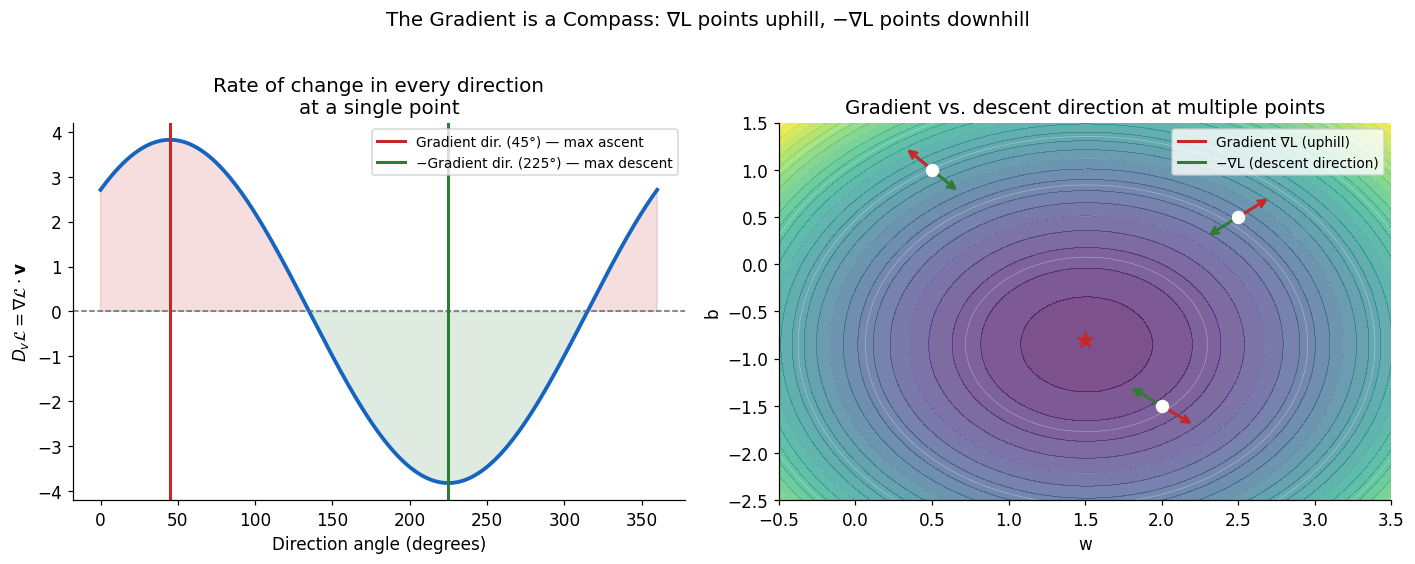

In [9]:
# 🖼 PLOT — Directional derivative as a function of angle

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: directional derivative vs angle
w0, b0    = 2.5, 0.5   # a point on the surface (not at minimum)
grad_w, grad_b = mse_grad(w0, b0, x_true, y_true)
grad_mag  = np.sqrt(grad_w**2 + grad_b**2)
grad_angle = np.arctan2(grad_b, grad_w)   # angle of gradient vector

phi_range = np.linspace(0, 2*np.pi, 300)
# directional derivative = |∇L| cos(φ - grad_angle)
dir_deriv = grad_mag * np.cos(phi_range - grad_angle)

ax = axes[0]
ax.plot(np.degrees(phi_range), dir_deriv, color=C['blue'], lw=2.5)
ax.axhline(0, color=C['grey'], ls='--', lw=1)
ax.axvline(np.degrees(grad_angle), color=C['red'], ls='-', lw=2,
           label=f'Gradient dir. ({np.degrees(grad_angle):.0f}°) — max ascent')
ax.axvline(np.degrees(grad_angle + np.pi), color=C['green'], ls='-', lw=2,
           label=f'−Gradient dir. ({np.degrees(grad_angle+np.pi):.0f}°) — max descent')
ax.fill_between(np.degrees(phi_range), dir_deriv, 0,
                where=dir_deriv > 0, alpha=0.15, color=C['red'])
ax.fill_between(np.degrees(phi_range), dir_deriv, 0,
                where=dir_deriv < 0, alpha=0.15, color=C['green'])
ax.set_xlabel('Direction angle (degrees)')
ax.set_ylabel(r'$D_v \mathcal{L} = \nabla\mathcal{L} \cdot \mathbf{v}$')
ax.set_title('Rate of change in every direction\nat a single point')
ax.legend(fontsize=9)

# Right: loss surface with gradient and descent arrows at several points
w_pts = [0.5, 2.5, 2.0]
b_pts = [1.0, 0.5, -1.5]

# Loss contour
w_r2 = np.linspace(-0.5, 3.5, 60)
b_r2 = np.linspace(-2.5, 1.5, 60)
W2, B2 = np.meshgrid(w_r2, b_r2)
L2 = np.array([[mse_loss(w, b, x_true, y_true)
                for w in w_r2] for b in b_r2])

ax = axes[1]
ax.contourf(W2, B2, L2, levels=30, cmap='viridis', alpha=0.7)
ax.contour(W2, B2, L2, levels=12, colors='white', linewidths=0.4, alpha=0.4)
ax.scatter([1.5], [-0.8], color=C['red'], s=120, zorder=6, marker='*', label='Minimum')

for wp, bp in zip(w_pts, b_pts):
    gw, gb = mse_grad(wp, bp, x_true, y_true)
    scale  = 0.3 / (np.sqrt(gw**2 + gb**2) + 1e-8)
    # Gradient (uphill)
    ax.annotate('', xy=(wp + gw*scale, bp + gb*scale), xytext=(wp, bp),
                arrowprops=dict(arrowstyle='->', color=C['red'], lw=2))
    # Negative gradient (downhill)
    ax.annotate('', xy=(wp - gw*scale, bp - gb*scale), xytext=(wp, bp),
                arrowprops=dict(arrowstyle='->', color=C['green'], lw=2))
    ax.scatter([wp], [bp], s=60, color='white', zorder=5)

# Legend proxies
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color=C['red'],   lw=2, label='Gradient ∇L (uphill)'),
    Line2D([0],[0], color=C['green'], lw=2, label='−∇L (descent direction)'),
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_xlabel('w'); ax.set_ylabel('b')
ax.set_title('Gradient vs. descent direction at multiple points')

plt.suptitle('The Gradient is a Compass: ∇L points uphill, −∇L points downhill',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## Section 7 — Gradient Descent: The Full Algorithm

We now have everything we need.

### The update rule

$$\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}$$

In our case:

$$w \leftarrow w - \eta \frac{\partial \mathcal{L}}{\partial w}, \qquad
  b \leftarrow b - \eta \frac{\partial \mathcal{L}}{\partial b}$$

$\eta$ (eta) is the **learning rate** — how large a step we take each iteration.

### Why does this converge?

At each step, we move in the direction that **locally** decreases the loss most.  
For a convex function (like our MSE bowl) this is **guaranteed** to converge  
to the global minimum, provided $\eta$ is small enough.

For non-convex functions (neural networks), we converge to *a* minimum, not necessarily the *global* minimum — but empirically this works very well in practice.

### Algorithm

```
Initialise w, b randomly
For each iteration:
    1. Compute predictions:  ŷ = w·x + b
    2. Compute loss:         L = MSE(ŷ, y)
    3. Compute gradients:    ∂L/∂w,  ∂L/∂b
    4. Update parameters:    w ← w − η·∂L/∂w
                             b ← b − η·∂L/∂b
```


In [10]:
# ⚙ IMPLEMENTATION — Gradient descent for linear regression, fully annotated

def gradient_descent_linear(x, y, lr=0.1, n_iters=200, w_init=3.0, b_init=1.5,
                             record_every=1):
    """
    Full gradient descent on a linear model with MSE loss.
    Records the trajectory in (w, b, loss) space.
    """
    w, b   = w_init, b_init
    history = {'w': [w], 'b': [b], 'loss': [mse_loss(w, b, x, y)]}

    for i in range(n_iters):
        # Step 1: forward pass
        y_hat = w * x + b

        # Step 2: loss (just for logging)
        loss  = np.mean((y_hat - y)**2)

        # Step 3: gradients (derived in Section 5)
        residuals = y_hat - y
        dL_dw = 2 * np.mean(residuals * x)
        dL_db = 2 * np.mean(residuals)

        # Step 4: update
        w = w - lr * dL_dw
        b = b - lr * dL_db

        if i % record_every == 0:
            history['w'].append(w)
            history['b'].append(b)
            history['loss'].append(loss)

    return w, b, history


w_final, b_final, hist = gradient_descent_linear(
    x_true, y_true, lr=0.1, n_iters=300, w_init=3.0, b_init=1.5)

print(f"Starting point:  w=3.00, b=1.50  |  Loss={hist['loss'][0]:.4f}")
print(f"After training:  w={w_final:.4f}, b={b_final:.4f}  |  Loss={hist['loss'][-1]:.4f}")
print(f"True parameters: w=1.50, b=-0.80  |  Loss={mse_loss(1.5,-0.8,x_true,y_true):.4f}")


Starting point:  w=3.00, b=1.50  |  Loss=8.7023
After training:  w=1.5095, b=-0.8495  |  Loss=0.1447
True parameters: w=1.50, b=-0.80  |  Loss=0.1473


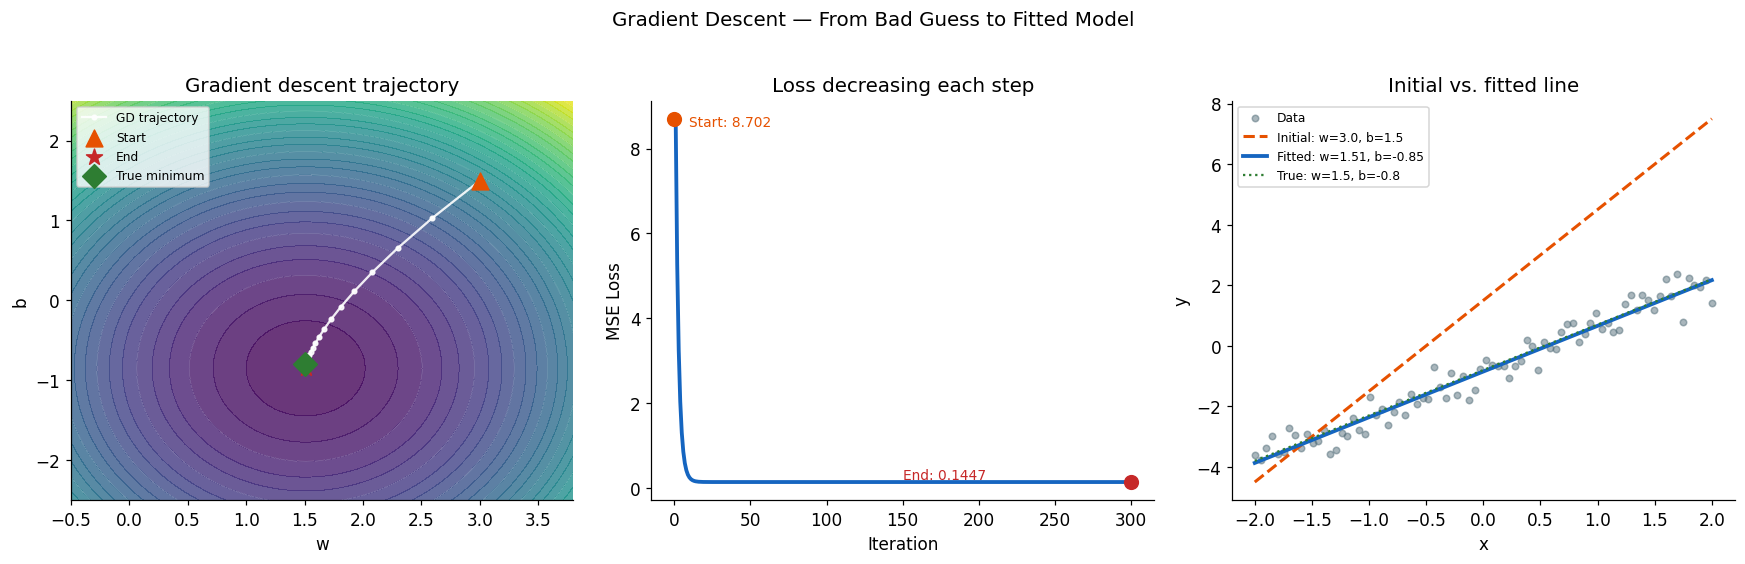

In [11]:
# 🖼 PLOT — The descent trajectory overlaid on the loss surface

# Pre-compute loss grid
w_rng = np.linspace(-0.5, 3.8, 80)
b_rng = np.linspace(-2.5, 2.5, 80)
Wg, Bg = np.meshgrid(w_rng, b_rng)
Lg = np.array([[mse_loss(w, b, x_true, y_true) for w in w_rng] for b in b_rng])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Trajectory on contour map ───────────────────────────────────────
ax = axes[0]
ax.contourf(Wg, Bg, Lg, levels=40, cmap='viridis', alpha=0.8)
ax.contour( Wg, Bg, Lg, levels=15, colors='white', linewidths=0.4, alpha=0.4)

ws  = hist['w'];   bs  = hist['b']
ax.plot(ws, bs, 'o-', color='white', lw=1.5, ms=3, alpha=0.9, label='GD trajectory')
ax.scatter([ws[0]],  [bs[0]],  s=120, color=C['orange'], zorder=6,
           marker='^', label='Start')
ax.scatter([ws[-1]], [bs[-1]], s=120, color=C['red'],    zorder=6,
           marker='*', label='End')
ax.scatter([1.5], [-0.8], s=120, color=C['green'], zorder=6,
           marker='D', label='True minimum')
ax.set_xlabel('w'); ax.set_ylabel('b')
ax.set_title('Gradient descent trajectory')
ax.legend(fontsize=8)

# ── Panel 2: Loss curve ───────────────────────────────────────────────────────
ax = axes[1]
ax.plot(hist['loss'], color=C['blue'], lw=2.5)
ax.set_xlabel('Iteration');  ax.set_ylabel('MSE Loss')
ax.set_title('Loss decreasing each step')

# Annotate key points
ax.scatter([0],   [hist['loss'][0]],  s=80, color=C['orange'], zorder=5)
ax.scatter([len(hist['loss'])-1], [hist['loss'][-1]], s=80, color=C['red'], zorder=5)
ax.text(10, hist['loss'][0]*0.98, f"Start: {hist['loss'][0]:.3f}", fontsize=9,
        color=C['orange'])
ax.text(len(hist['loss'])*0.5, hist['loss'][-1]*1.5,
        f"End: {hist['loss'][-1]:.4f}", fontsize=9, color=C['red'])

# ── Panel 3: Fitted line vs data ──────────────────────────────────────────────
ax = axes[2]
ax.scatter(x_true, y_true, s=18, color=C['grey'], alpha=0.5, label='Data')
ax.plot(x_true, 3.0*x_true + 1.5,     color=C['orange'], lw=2, ls='--',
        label=f'Initial: w=3.0, b=1.5')
ax.plot(x_true, w_final*x_true+b_final, color=C['blue'], lw=2.5,
        label=f'Fitted: w={w_final:.2f}, b={b_final:.2f}')
ax.plot(x_true, 1.5*x_true - 0.8,      color=C['green'], lw=1.5, ls=':',
        label='True: w=1.5, b=-0.8')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Initial vs. fitted line')
ax.legend(fontsize=8)

plt.suptitle('Gradient Descent — From Bad Guess to Fitted Model', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## Section 8 — Learning Rate: Too Small, Too Large, Just Right

The learning rate $\eta$ is the most important hyperparameter in training.

| Learning rate | Effect |
|--------------|--------|
| Too small | Converges, but takes many more steps |
| Just right | Converges efficiently |
| Too large | Overshoots the minimum, may oscillate or diverge |
| Way too large | Loss explodes — parameters blow up |

### Why too large diverges

At step $k$, the update is $w_{k+1} = w_k - \eta \cdot g_k$ where $g_k = \nabla\mathcal{L}(w_k)$.  
If $\eta$ is too large, $w_{k+1}$ overshoots to a region where the gradient is even larger,  
and the next step overshoots further. The loss grows without bound.

For a quadratic loss, convergence is guaranteed when $\eta < \frac{1}{L}$  
where $L$ is the Lipschitz constant of the gradient (roughly: the curvature).


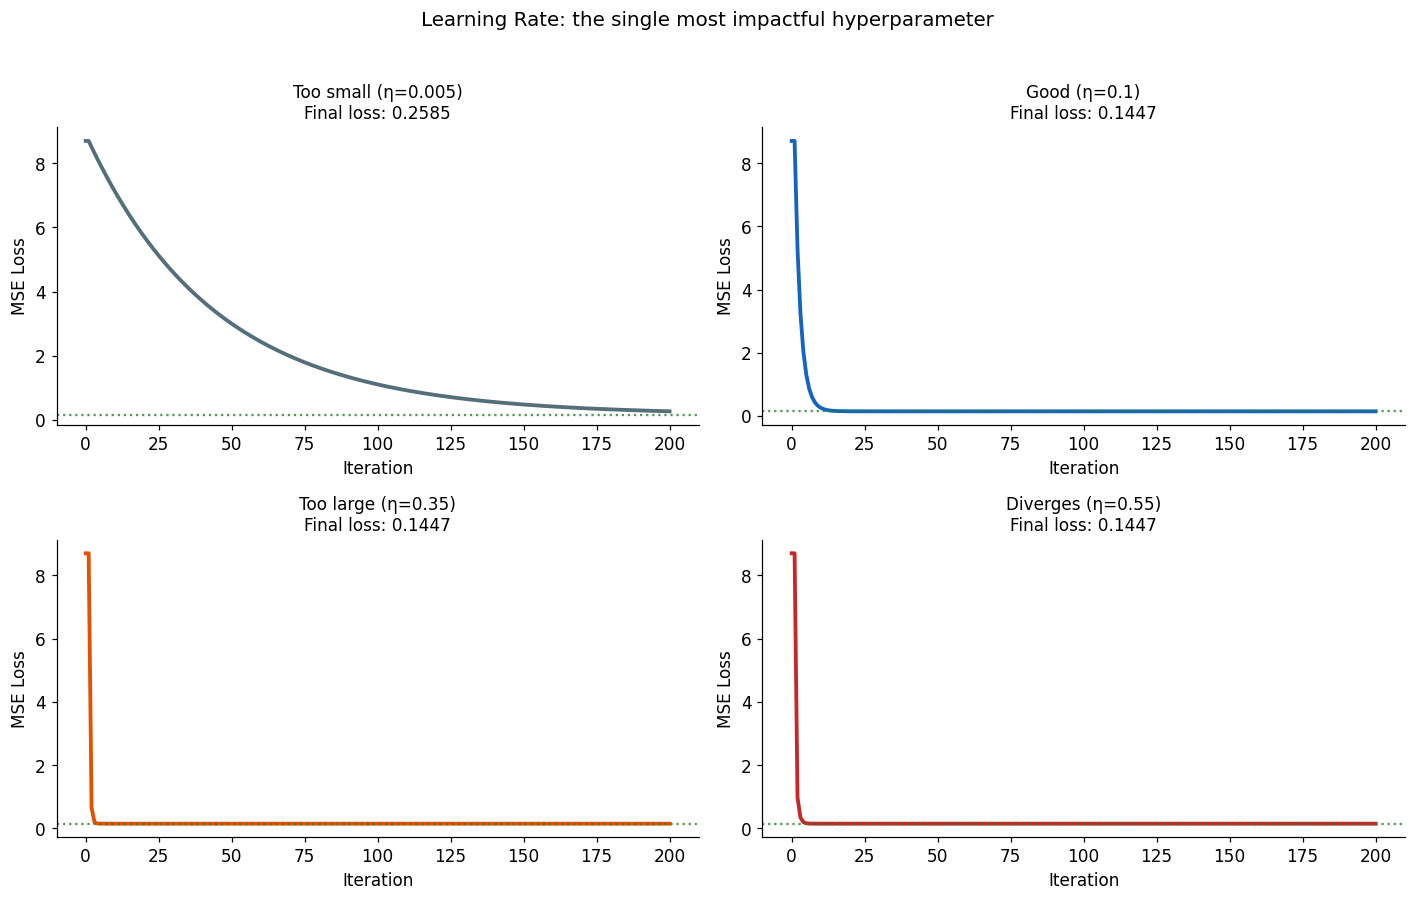

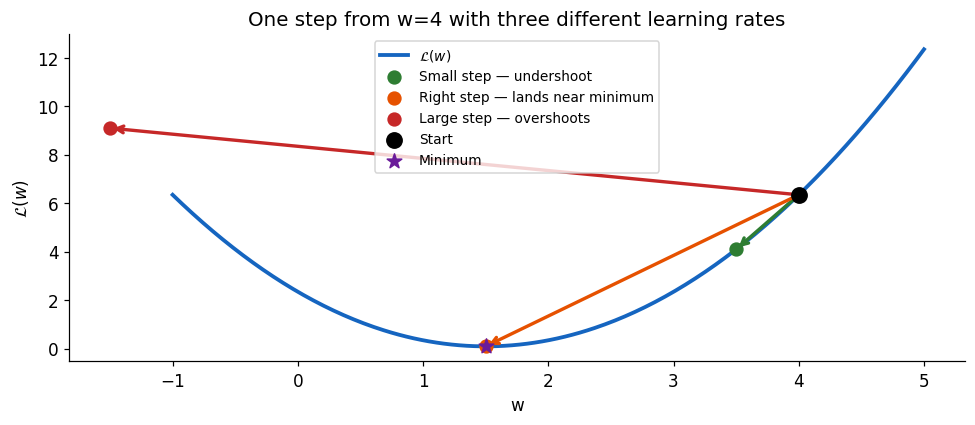

In [12]:
# 🖼 PLOT — Four learning rates, one plot each

learning_rates = [0.005, 0.1, 0.35, 0.55]
lr_labels      = ['Too small (η=0.005)', 'Good (η=0.1)',
                  'Too large (η=0.35)', 'Diverges (η=0.55)']
lr_colors      = [C['grey'], C['blue'], C['orange'], C['red']]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes      = axes.flatten()

for ax, lr, label, col in zip(axes, learning_rates, lr_labels, lr_colors):
    try:
        w_f, b_f, h = gradient_descent_linear(
            x_true, y_true, lr=lr, n_iters=200, w_init=3.0, b_init=1.5)
        losses = h['loss']
        ws, bs = h['w'], h['b']

        # Cap explosive losses for display
        losses_disp = [min(l, 50) for l in losses]

        ax.plot(losses_disp, color=col, lw=2.5)
        ax.set_ylabel('MSE Loss')

        if losses[-1] < 1e3:
            ax.set_title(f'{label}\nFinal loss: {losses[-1]:.4f}', fontsize=11)
        else:
            ax.set_title(f'{label}\nDIVERGED (loss → ∞)', fontsize=11, color=C['red'])

        if max(losses) > 30:
            ax.set_ylim(0, 55)
            ax.text(len(losses)*0.4, 30, '⚠ Loss exploding',
                    color=C['red'], fontsize=11, fontweight='bold')

    except Exception as e:
        ax.set_title(f'{label}\nNumerical overflow', color=C['red'])

    ax.set_xlabel('Iteration')
    hline(ax, mse_loss(1.5, -0.8, x_true, y_true), color=C['green'],
           ls=':', lw=1.5, alpha=0.8)

plt.suptitle('Learning Rate: the single most impactful hyperparameter', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── 1D illustration: where η overshoots ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
w_1d = np.linspace(-1, 5, 300)
L_1d = (w_1d - 1.5)**2 + 0.1   # simple quadratic centred at w=1.5

ax.plot(w_1d, L_1d, color=C['blue'], lw=2.5, label=r'$\mathcal{L}(w)$')

# Show three step sizes from w=4
w_curr = 4.0
grad_1d = 2*(w_curr - 1.5)   # dL/dw = 2(w - 1.5)

for lr_1d, col, lbl in [(0.1, C['green'], 'Small step — undershoot'),
                         (0.5, C['orange'], 'Right step — lands near minimum'),
                         (1.1, C['red'],   'Large step — overshoots')]:
    w_next = w_curr - lr_1d * grad_1d
    ax.annotate('', xy=(w_next, (w_next-1.5)**2+0.1), xytext=(w_curr, (w_curr-1.5)**2+0.1),
                arrowprops=dict(arrowstyle='->', color=col, lw=2.2))
    ax.scatter([w_next], [(w_next-1.5)**2+0.1], s=70, color=col, zorder=5, label=lbl)

ax.scatter([w_curr], [(w_curr-1.5)**2+0.1], s=100, color='black', zorder=6, label='Start')
ax.scatter([1.5], [0.1], s=100, color=C['purple'], zorder=6, marker='*', label='Minimum')
ax.set_xlabel('w'); ax.set_ylabel(r'$\mathcal{L}(w)$')
ax.set_title('One step from w=4 with three different learning rates')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## Section 9 — The Chain Rule in Depth: Composing Derivatives

The chain rule is the **entire mathematical foundation of backpropagation**.  
It is worth understanding deeply, not just mechanically.

### The intuition

If a small change in $x$ causes a change in $u$,  
and a small change in $u$ causes a change in $y$,  
then the total effect of a small change in $x$ on $y$ is the **product** of those effects.

$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$

### A 3-step chain (preview of a neural network layer)

Consider: $\mathcal{L} = \text{loss}(\hat{y})$, $\hat{y} = \sigma(z)$, $z = wx + b$

$$\frac{\partial \mathcal{L}}{\partial w} =
  \underbrace{\frac{\partial \mathcal{L}}{\partial \hat{y}}}_{\text{loss gradient}}
  \cdot
  \underbrace{\frac{\partial \hat{y}}{\partial z}}_{\sigma'(z)}
  \cdot
  \underbrace{\frac{\partial z}{\partial w}}_{x}$$

This is **exactly** the calculation performed in the backward pass of a single neuron.


In [13]:
# 🔍 DERIVATION — 3-step chain rule worked through a single neuron

def sigma(z): return 1 / (1 + np.exp(-z))
def sigma_prime(z): s = sigma(z); return s * (1 - s)

# Single training example
x_eg  = np.array([2.0, -1.0, 0.5])    # 3-dimensional input
w_eg  = np.array([0.4, -0.2,  0.7])   # weights
b_eg  = 0.1                             # bias
y_eg  = 1.0                             # true label

# ── Forward pass ──────────────────────────────────────────────────────────────
z_eg    = np.dot(w_eg, x_eg) + b_eg    # linear combination
y_hat_e = sigma(z_eg)                  # sigmoid activation
loss_eg = -(y_eg*np.log(y_hat_e+1e-12) + (1-y_eg)*np.log(1-y_hat_e+1e-12))

print("=== Single Neuron — Forward Pass ===")
print(f"  z    = w·x + b = {np.dot(w_eg,x_eg):.4f} + {b_eg} = {z_eg:.4f}")
print(f"  ŷ    = σ(z)    = {y_hat_e:.6f}")
print(f"  Loss = BCE     = {loss_eg:.6f}")

# ── Backward pass (chain rule) ────────────────────────────────────────────────
# Step 1: dL/dŷ  — gradient of BCE loss w.r.t. output
dL_dyhat = -(y_eg/(y_hat_e+1e-12) - (1-y_eg)/(1-y_hat_e+1e-12))

# Step 2: dŷ/dz  — gradient of sigmoid w.r.t. pre-activation
dyhat_dz = sigma_prime(z_eg)

# Step 3: dz/dw  — gradient of linear function w.r.t. weights (= x)
dz_dw    = x_eg

# Chain rule product
dL_dw    = dL_dyhat * dyhat_dz * dz_dw
dL_db    = dL_dyhat * dyhat_dz * 1.0   # dz/db = 1

print()
print("=== Backward Pass — Chain Rule ===")
print(f"  Step 1  dL/dŷ  = -(y/ŷ - (1-y)/(1-ŷ)) = {dL_dyhat:.6f}")
print(f"  Step 2  dŷ/dz  = σ(z)·(1-σ(z))         = {dyhat_dz:.6f}")
print(f"  Step 3  dz/dw  = x                       = {dz_dw}")
print()
print(f"  dL/dw = dL/dŷ · dŷ/dz · dz/dw")
print(f"        = {dL_dyhat:.4f} × {dyhat_dz:.4f} × {dz_dw}")
print(f"        = {dL_dw}")
print(f"  dL/db = dL/dŷ · dŷ/dz · 1 = {dL_db:.6f}")

# ── Numerical gradient check ──────────────────────────────────────────────────
def single_neuron_loss(w, b, x, y):
    z = np.dot(w, x) + b
    yh = sigma(z)
    return -(y*np.log(yh+1e-12) + (1-y)*np.log(1-yh+1e-12))

h_fd = 1e-5
dw_num = np.zeros(3)
for i in range(3):
    w_p, w_m = w_eg.copy(), w_eg.copy()
    w_p[i] += h_fd; w_m[i] -= h_fd
    dw_num[i] = (single_neuron_loss(w_p,b_eg,x_eg,y_eg) -
                 single_neuron_loss(w_m,b_eg,x_eg,y_eg)) / (2*h_fd)

print()
print("=== Gradient Check ===")
print(f"{'':5} {'Analytical':>14}  {'Numerical':>14}  {'Error':>12}")
for i in range(3):
    err = abs(dL_dw[i] - dw_num[i])
    print(f"  w[{i}]  {dL_dw[i]:>14.8f}  {dw_num[i]:>14.8f}  {err:>12.2e}")
print("\n✓ Chain rule derivation verified numerically.")


=== Single Neuron — Forward Pass ===
  z    = w·x + b = 1.3500 + 0.1 = 1.4500
  ŷ    = σ(z)    = 0.809998
  Loss = BCE     = 0.210723

=== Backward Pass — Chain Rule ===
  Step 1  dL/dŷ  = -(y/ŷ - (1-y)/(1-ŷ)) = -1.234570
  Step 2  dŷ/dz  = σ(z)·(1-σ(z))         = 0.153901
  Step 3  dz/dw  = x                       = [ 2.  -1.   0.5]

  dL/dw = dL/dŷ · dŷ/dz · dz/dw
        = -1.2346 × 0.1539 × [ 2.  -1.   0.5]
        = [-0.38000313  0.19000157 -0.09500078]
  dL/db = dL/dŷ · dŷ/dz · 1 = -0.190002

=== Gradient Check ===
          Analytical       Numerical         Error
  w[0]     -0.38000313     -0.38000313      1.98e-11
  w[1]      0.19000157      0.19000157      3.96e-12
  w[2]     -0.09500078     -0.09500078      8.92e-12

✓ Chain rule derivation verified numerically.


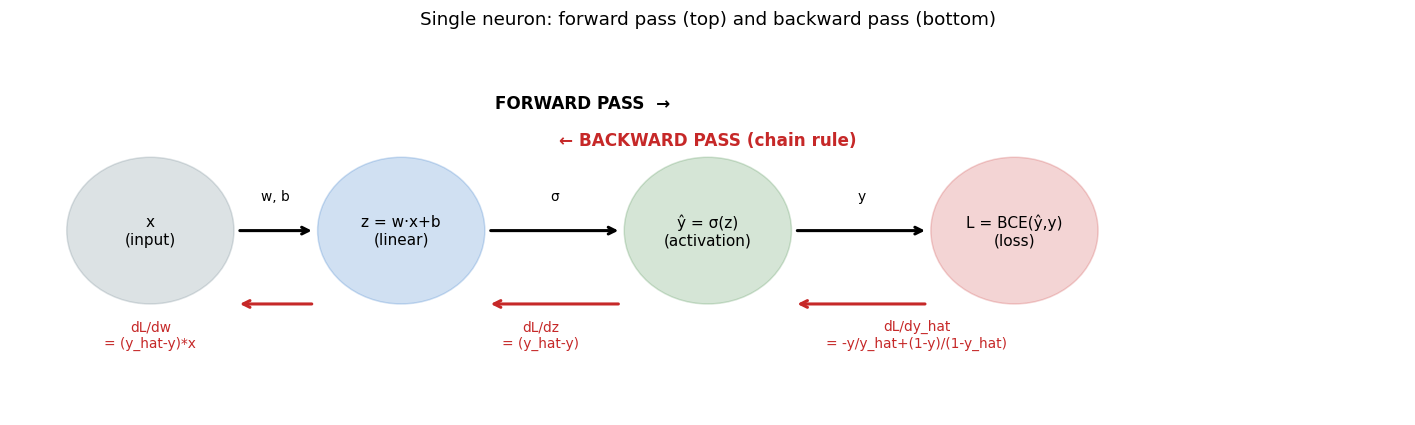

The backward pass walks this graph RIGHT TO LEFT.
Each node multiplies its incoming gradient by its local derivative.
This is exactly what PyTorch's .backward() does — across millions of nodes.


In [14]:
# 🖼 PLOT — Visualising the chain of dependencies

fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')
ax.set_xlim(0, 10); ax.set_ylim(0, 3)

# Nodes
nodes = [
    (1.0, 1.5, 'x\n(input)', C['grey']),
    (2.8, 1.5, 'z = w·x+b\n(linear)', C['blue']),
    (5.0, 1.5, 'ŷ = σ(z)\n(activation)', C['green']),
    (7.2, 1.5, 'L = BCE(ŷ,y)\n(loss)', C['red']),
]
for nx, ny, lbl, col in nodes:
    circ = plt.Circle((nx, ny), 0.6, color=col, alpha=0.2, zorder=2)
    ax.add_patch(circ)
    ax.text(nx, ny, lbl, ha='center', va='center', fontsize=10, zorder=3)

# Forward arrows
for (x1,_,_,_), (x2,_,_,_) in zip(nodes, nodes[1:]):
    ax.annotate('', xy=(x2-0.62, 1.5), xytext=(x1+0.62, 1.5),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Forward labels
fwd_labels = ['w, b', 'σ', 'y']
fwd_x      = [1.9, 3.9, 6.1]
for lbl, xp in zip(fwd_labels, fwd_x):
    ax.text(xp, 1.75, lbl, ha='center', fontsize=9, color='black')  # fwd label

ax.text(4.1, 2.5, 'FORWARD PASS  →', ha='center', fontsize=11,
        color='black', fontweight='bold')

# Backward arrows (below)
bwd_labels = ['dL/dw = dL/dŷ · dŷ/dz · x', 'dL/dŷ · dŷ/dz', 'dL/dŷ']
bwd_x      = [3.9, 5.5, 6.6]
bwd_pairs  = [(7.2, 5.0), (5.0, 2.8), (2.8, 1.0)]
for (x2, x1), lbl in zip(bwd_pairs, bwd_labels[::-1]):
    ax.annotate('', xy=(x1+0.62, 0.9), xytext=(x2-0.62, 0.9),
                arrowprops=dict(arrowstyle='->', color=C['red'], lw=2))

ax.text(5.0, 2.2, '← BACKWARD PASS (chain rule)', ha='center', fontsize=11,
        color=C['red'], fontweight='bold')

ax.text(1.0, 0.55, 'dL/dw\n= (y_hat-y)*x', ha='center', fontsize=9, color=C['red'])
ax.text(3.8, 0.55, 'dL/dz\n= (y_hat-y)', ha='center', fontsize=9, color=C['red'])
ax.text(6.5, 0.55, 'dL/dy_hat\n= -y/y_hat+(1-y)/(1-y_hat)', ha='center', fontsize=9, color=C['red'])

ax.set_title('Single neuron: forward pass (top) and backward pass (bottom)',
             fontsize=12, pad=15)
plt.tight_layout()
plt.show()

print("The backward pass walks this graph RIGHT TO LEFT.")
print("Each node multiplies its incoming gradient by its local derivative.")
print("This is exactly what PyTorch's .backward() does — across millions of nodes.")


---
## Section 10 — Non-Convex Loss Surfaces: Local Minima & Saddle Points

The MSE loss for a linear model is a **convex bowl** — one global minimum,  
gradient descent always finds it.

Neural networks have **non-convex** loss surfaces with:
- **Local minima** — lower than all nearby points, but not the global minimum
- **Saddle points** — a minimum in one direction, maximum in another
- **Flat regions / plateaus** — gradient is near zero, learning stalls

### Key insight: saddle points are more common than local minima

In high dimensions, a local minimum requires the function to curve **upward  
in every direction simultaneously** — exponentially unlikely.  
Saddle points only require some directions to curve up, others down.  
Research suggests most "local minima" for neural networks are actually saddle points  
at similar loss values to the global minimum.


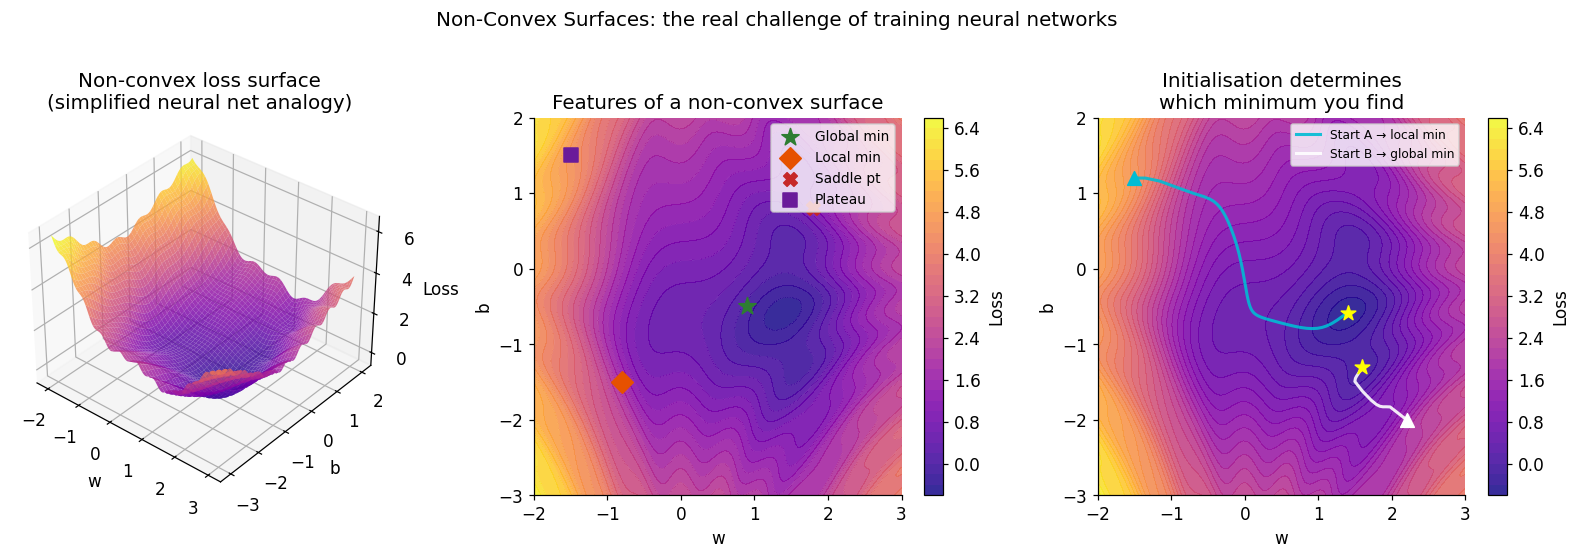

Key insight: with a non-convex surface, the starting point matters.
This is why weight initialisation (Notebook 2, Section 7) is non-trivial.


In [15]:
# 🖼 PLOT — Non-convex surface with local minima, saddle point, plateau

def non_convex(w, b):
    """A hand-crafted non-convex function for illustration."""
    return (0.3*np.sin(3*w) + 0.2*np.sin(2*b) +
            0.5*(w-1)**2 + 0.3*(b+0.5)**2 +
            0.15*np.cos(4*w*b))

w_nc = np.linspace(-2, 3, 150)
b_nc = np.linspace(-3, 2, 150)
W_nc, B_nc = np.meshgrid(w_nc, b_nc)
L_nc = non_convex(W_nc, B_nc)

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# ── 3D surface ────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0], projection='3d')
ax3.plot_surface(W_nc, B_nc, L_nc, cmap='plasma', alpha=0.8, linewidth=0)
ax3.set_xlabel('w'); ax3.set_ylabel('b'); ax3.set_zlabel('Loss')
ax3.set_title('Non-convex loss surface\n(simplified neural net analogy)')
ax3.view_init(elev=35, azim=-50)

# ── 2D contour with annotated features ───────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
cf  = ax2.contourf(W_nc, B_nc, L_nc, levels=40, cmap='plasma', alpha=0.85)
ax2.contour(W_nc, B_nc, L_nc, levels=20, colors='white', linewidths=0.3, alpha=0.3)

# Mark approximate special points
special_pts = [
    ( 0.9, -0.5, C['green'],  '*', 140, 'Global min'),
    (-0.8, -1.5, C['orange'], 'D', 100, 'Local min'),
    ( 1.8,  0.8, C['red'],    'X',  80, 'Saddle pt'),
    (-1.5,  1.5, C['purple'], 's',  80, 'Plateau'),
]
for wp, bp, col, mk, sz, lbl in special_pts:
    ax2.scatter([wp], [bp], color=col, marker=mk, s=sz, zorder=5, label=lbl)
ax2.set_xlabel('w'); ax2.set_ylabel('b')
ax2.set_title('Features of a non-convex surface')
ax2.legend(fontsize=9, loc='upper right')
plt.colorbar(cf, ax=ax2, label='Loss')

# ── Two trajectories from different starting points ───────────────────────────
ax3b = fig.add_subplot(gs[2])
cf2  = ax3b.contourf(W_nc, B_nc, L_nc, levels=40, cmap='plasma', alpha=0.85)

def gd_nonconvex(w0, b0, lr=0.08, n=120):
    """Numerical gradient descent on non-convex surface."""
    w, b    = w0, b0
    ws, bs  = [w], [b]
    h_delta = 1e-4
    for _ in range(n):
        gw = (non_convex(w+h_delta, b) - non_convex(w-h_delta, b)) / (2*h_delta)
        gb = (non_convex(w, b+h_delta) - non_convex(w, b-h_delta)) / (2*h_delta)
        w -= lr * gw; b -= lr * gb
        ws.append(w); bs.append(b)
    return ws, bs

starts = [(-1.5, 1.2, '#00BCD4',  'Start A → local min'),
          ( 2.2,-2.0, 'white', 'Start B → global min')]
for w0, b0, col, lbl in starts:
    ws, bs = gd_nonconvex(w0, b0, lr=0.07, n=150)
    ax3b.plot(ws, bs, '-', color=col, lw=2, alpha=0.9, label=lbl)
    ax3b.scatter([ws[0]],  [bs[0]],  s=80,  color=col,      marker='^', zorder=5)
    ax3b.scatter([ws[-1]], [bs[-1]], s=100, color='yellow', marker='*', zorder=5)

ax3b.set_xlabel('w'); ax3b.set_ylabel('b')
ax3b.set_title('Initialisation determines\nwhich minimum you find')
ax3b.legend(fontsize=8)
plt.colorbar(cf2, ax=ax3b, label='Loss')

plt.suptitle('Non-Convex Surfaces: the real challenge of training neural networks',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Key insight: with a non-convex surface, the starting point matters.")
print("This is why weight initialisation (Notebook 2, Section 7) is non-trivial.")


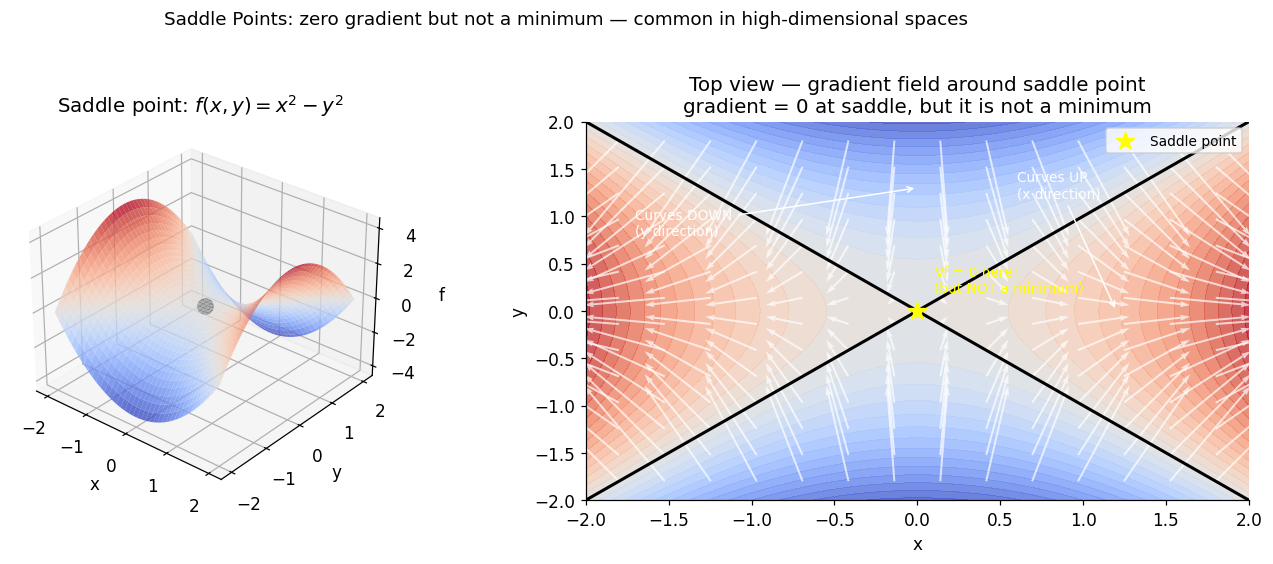

At a saddle point: gradient = 0, second derivative is positive in some
directions and negative in others. Vanilla GD can stall here.
Momentum (Notebook 2) helps escape saddle points.


In [16]:
# 🖼 PLOT — What a saddle point looks like, and why gradients lie

def saddle(x, y): return x**2 - y**2

x_s = np.linspace(-2, 2, 80)
y_s = np.linspace(-2, 2, 80)
Xs, Ys = np.meshgrid(x_s, y_s)
Zs     = saddle(Xs, Ys)

fig = plt.figure(figsize=(13, 5))

# 3D saddle
ax3 = fig.add_subplot(121, projection='3d')
ax3.plot_surface(Xs, Ys, Zs, cmap='coolwarm', alpha=0.8)
ax3.scatter([0], [0], [0], color='black', s=100, zorder=5)
ax3.set_title(r'Saddle point: $f(x,y) = x^2 - y^2$')
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('f')
ax3.view_init(elev=30, azim=-50)

# 2D contour with gradient field
ax2 = fig.add_subplot(122)
ax2.contourf(Xs, Ys, Zs, levels=30, cmap='coolwarm', alpha=0.8)
ax2.contour(Xs, Ys, Zs, levels=[0], colors='black', linewidths=2)

# Gradient of saddle: df/dx=2x, df/dy=-2y
x_q = np.linspace(-1.8, 1.8, 14)
y_q = np.linspace(-1.8, 1.8, 14)
Xq, Yq = np.meshgrid(x_q, y_q)
DXq, DYq = 2*Xq, -2*Yq

ax2.quiver(Xq, Yq, DXq, DYq, color='white', alpha=0.7, scale=25, width=0.003)
ax2.scatter([0], [0], color='yellow', s=150, zorder=5, marker='*',
            label='Saddle point')
ax2.text(0.1, 0.2, '∇f = 0 here!\n(but NOT a minimum)', color='yellow', fontsize=9)

ax2.annotate('Curves UP\n(x direction)', xy=(1.2, 0), xytext=(0.6, 1.2),
             arrowprops=dict(arrowstyle='->', color='white'), color='white', fontsize=9)
ax2.annotate('Curves DOWN\n(y direction)', xy=(0, 1.3), xytext=(-1.7, 0.8),
             arrowprops=dict(arrowstyle='->', color='white'), color='white', fontsize=9)

ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('Top view — gradient field around saddle point\n'
              'gradient = 0 at saddle, but it is not a minimum')
ax2.legend(fontsize=9)

plt.suptitle('Saddle Points: zero gradient but not a minimum — '
             'common in high-dimensional spaces', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("At a saddle point: gradient = 0, second derivative is positive in some")
print("directions and negative in others. Vanilla GD can stall here.")
print("Momentum (Notebook 2) helps escape saddle points.")


---
## Section 11 — From Scalars to Vectors: Matrix Calculus Preview

So far everything has been scalar — one weight $w$, one bias $b$.  
Neural networks have thousands of weights. We need to generalise.

### The Jacobian

For a function $\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^m$,  
the **Jacobian** $J \in \mathbb{R}^{m \times n}$ collects all partial derivatives:

$$J_{ij} = \frac{\partial f_i}{\partial x_j}$$

For our layer $\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b}$:

$$\frac{\partial \mathbf{z}}{\partial \mathbf{x}} = \mathbf{W}, \qquad
  \frac{\partial \mathbf{z}}{\partial \mathbf{W}} = \mathbf{x}^\top$$

### The vector chain rule

For $\mathcal{L} = f(\mathbf{z}(\mathbf{x}))$:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{x}} =
  \mathbf{W}^\top \frac{\partial \mathcal{L}}{\partial \mathbf{z}}$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}} =
  \frac{\partial \mathcal{L}}{\partial \mathbf{z}} \, \mathbf{x}^\top$$

These two equations are the entire backpropagation algorithm for a linear layer.  
Everything in Notebook 2 is applying these formulas layer by layer.


In [17]:
# 🔍 DERIVATION — Vector gradients for a linear layer, verified numerically

def numerical_grad_vec(loss_fn, W, b, x, y, h=1e-5):
    """Compute gradients numerically for a matrix W and vector b."""
    dW = np.zeros_like(W)
    db = np.zeros_like(b)

    # Gradient w.r.t. W
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            W_p, W_m = W.copy(), W.copy()
            W_p[i,j] += h; W_m[i,j] -= h
            dW[i,j] = (loss_fn(W_p,b,x,y) - loss_fn(W_m,b,x,y)) / (2*h)

    # Gradient w.r.t. b
    for i in range(b.shape[0]):
        b_p, b_m = b.copy(), b.copy()
        b_p[i] += h; b_m[i] -= h
        db[i] = (loss_fn(W,b_p,x,y) - loss_fn(W,b_m,x,y)) / (2*h)

    return dW, db


def linear_mse_loss(W, b, x, y):
    """MSE loss for z = Wx + b."""
    z = W @ x + b
    return np.mean((z - y)**2)

def linear_mse_grad(W, b, x, y):
    """
    Analytical gradients using vector chain rule.
    dL/dz = 2(z-y)/n   [for MSE]
    dL/dW = dL/dz · x^T   [vector chain rule]
    dL/db = dL/dz
    """
    z      = W @ x + b
    dL_dz  = 2 * (z - y) / len(y)          # gradient of loss w.r.t. z
    dL_dW  = np.outer(dL_dz, x)             # outer product = dL/dz · x^T
    dL_db  = dL_dz                           # d(Wx+b)/db = I
    return dL_dW, dL_db


np.random.seed(SEED)
n_out, n_in = 3, 4
W_ex = np.random.randn(n_out, n_in) * 0.5
b_ex = np.random.randn(n_out) * 0.3
x_ex = np.random.randn(n_in)
y_ex = np.random.randn(n_out)

dW_ana, db_ana = linear_mse_grad(W_ex, b_ex, x_ex, y_ex)
dW_num, db_num = numerical_grad_vec(linear_mse_loss, W_ex, b_ex, x_ex, y_ex)

print("=== Vector Chain Rule — Gradient Check ===")
print(f"  Layer shape: W ∈ R^{n_out}×{n_in}, b ∈ R^{n_out}, x ∈ R^{n_in}")
print()
print(f"  dL/dW  max error: {np.max(np.abs(dW_ana - dW_num)):.2e}")
print(f"  dL/db  max error: {np.max(np.abs(db_ana - db_num)):.2e}")
print()
print("  Analytical dL/dW:")
print("  ", np.round(dW_ana, 6))
print("  Numerical  dL/dW:")
print("  ", np.round(dW_num, 6))
print()
print("✓ Vector chain rule verified: dL/dW = (dL/dz) · xᵀ")
print("  This is the formula repeated for every layer in backpropagation.")


=== Vector Chain Rule — Gradient Check ===
  Layer shape: W ∈ R^3×4, b ∈ R^3, x ∈ R^4

  dL/dW  max error: 1.63e-11
  dL/db  max error: 8.36e-12

  Analytical dL/dW:
   [[-0.309467 -0.557433  0.172953 -0.49975 ]
 [ 0.733045  1.320411 -0.409679  1.183775]
 [ 0.110897  0.199755 -0.061977  0.179085]]
  Numerical  dL/dW:
   [[-0.309467 -0.557433  0.172953 -0.49975 ]
 [ 0.733045  1.320411 -0.409679  1.183775]
 [ 0.110897  0.199755 -0.061977  0.179085]]

✓ Vector chain rule verified: dL/dW = (dL/dz) · xᵀ
  This is the formula repeated for every layer in backpropagation.


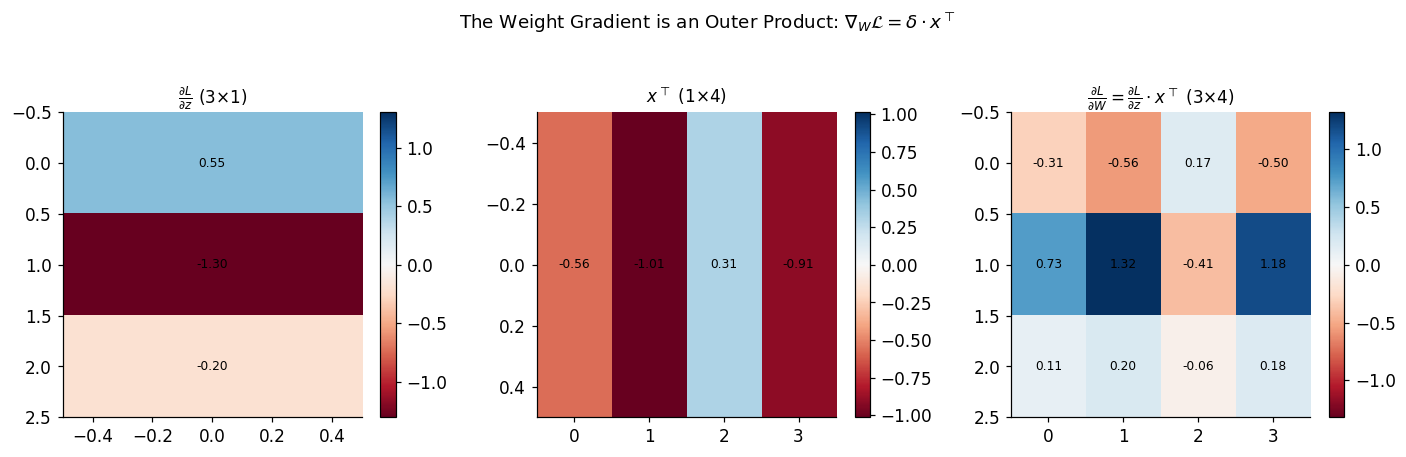

Each row of dL/dW corresponds to one output neuron.
Each column corresponds to one input feature.
Entry [i,j] = how much the loss changes if weight W[i,j] increases by 1.


In [18]:
# 🖼 PLOT — Visualise the outer product structure of dL/dW

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

def show_matrix(ax, M, title, cmap='RdBu'):
    im = ax.imshow(M, cmap=cmap, aspect='auto',
                   vmin=-np.abs(M).max(), vmax=np.abs(M).max())
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='black')

dL_dz_ex = 2*(W_ex @ x_ex + b_ex - y_ex) / len(y_ex)

show_matrix(axes[0], dL_dz_ex[:, None],  r'$\frac{\partial L}{\partial z}$ (3×1)')
show_matrix(axes[1], x_ex[None, :],       r'$x^\top$ (1×4)')
show_matrix(axes[2], np.outer(dL_dz_ex, x_ex),
            r'$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial z} \cdot x^\top$ (3×4)')

plt.suptitle(r'The Weight Gradient is an Outer Product: $\nabla_W \mathcal{L} = \delta \cdot x^\top$',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

print("Each row of dL/dW corresponds to one output neuron.")
print("Each column corresponds to one input feature.")
print("Entry [i,j] = how much the loss changes if weight W[i,j] increases by 1.")


---
## Section 12 — Putting It All Together: Fitting a Non-Linear Curve End-to-End

We now have everything we need to fit a non-linear model from scratch:

1. **Parameterised function** (Section 1)
2. **Loss surface** (Section 2)
3. **Derivatives** (Sections 3–4)
4. **Gradients** (Section 5)
5. **Gradient descent** (Section 7)
6. **Chain rule** for composed functions (Section 9)

We'll fit a **polynomial regression model** $\hat{y} = w_3 x^3 + w_2 x^2 + w_1 x + b$  
using gradient descent — no `sklearn`, no PyTorch, just the math from this notebook.

This is a direct preview of what a neural network does:  
each neuron is a non-linear function, the network composes many of them,  
and gradient descent minimises the loss by adjusting all the weights.


In [19]:
# ⚙ IMPLEMENTATION — Full gradient descent for polynomial regression from scratch

np.random.seed(SEED + 10)
x_poly = np.linspace(-2, 2, 120)
y_poly = 0.5*x_poly**3 - 1.2*x_poly**2 + 0.8*x_poly + 1.0 + np.random.randn(120)*0.3

# Feature matrix: [x^3, x^2, x, 1]
def poly_features(x):
    return np.column_stack([x**3, x**2, x, np.ones_like(x)])

X_feat = poly_features(x_poly)
n_params = X_feat.shape[1]   # 4

def forward(theta, X):
    return X @ theta

def mse(y_hat, y):
    return np.mean((y_hat - y)**2)

def grad_mse(theta, X, y):
    """
    Gradient of MSE for ŷ = Xθ.
    dL/dθ = (2/N) Xᵀ(ŷ - y)     [vector chain rule from Section 11]
    """
    residuals = X @ theta - y
    return 2 * X.T @ residuals / len(y)


# ── Training loop ──────────────────────────────────────────────────────────────
theta      = np.random.randn(n_params) * 0.1
lr_poly    = 0.02
n_iter_poly = 2000
losses_poly = []
snapshots   = {}

for i in range(n_iter_poly):
    y_hat = forward(theta, X_feat)
    loss  = mse(y_hat, y_poly)
    losses_poly.append(loss)

    grad = grad_mse(theta, X_feat, y_poly)
    theta = theta - lr_poly * grad

    if i in [0, 10, 50, 200, 999, 1999]:
        snapshots[i] = theta.copy()

print(f"Fitted polynomial coefficients:")
print(f"  x³: {theta[0]:.4f}  (true: 0.5)")
print(f"  x²: {theta[1]:.4f}  (true: -1.2)")
print(f"  x¹: {theta[2]:.4f}  (true: 0.8)")
print(f"  b : {theta[3]:.4f}  (true: 1.0)")
print(f"Final loss: {losses_poly[-1]:.5f}")


Fitted polynomial coefficients:
  x³: 0.4920  (true: 0.5)
  x²: -1.2200  (true: -1.2)
  x¹: 0.7965  (true: 0.8)
  b : 1.0579  (true: 1.0)
Final loss: 0.07762


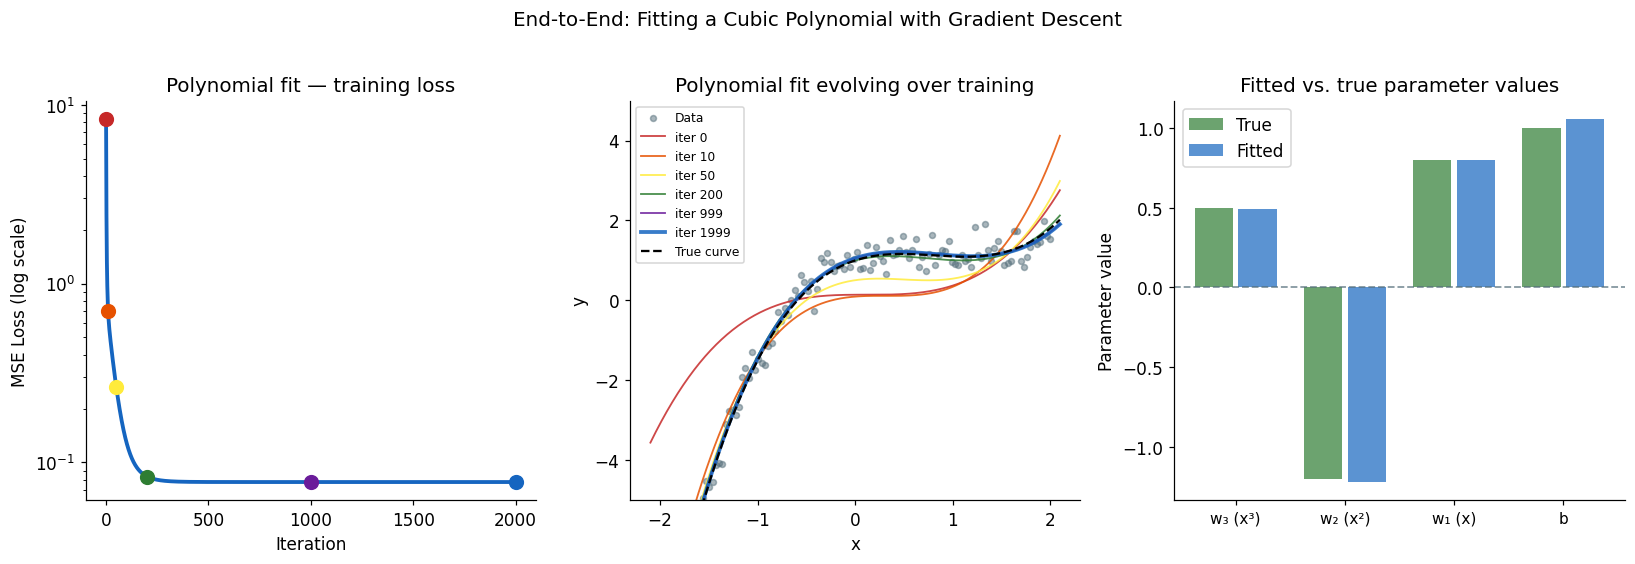

Gradient descent recovered the true parameters using only:
  1. A parameterised function  (Section 1)
  2. A loss function           (Section 2)
  3. The chain rule            (Section 9)
  4. The update rule           (Section 7)

A neural network does exactly this — with more layers and non-linearities.


In [20]:
# 🖼 PLOT — Watch the polynomial fit improve over training

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel 1: Loss curve ───────────────────────────────────────────────────────
ax = axes[0]
ax.semilogy(losses_poly, color=C['blue'], lw=2.5)
ax.set_xlabel('Iteration');  ax.set_ylabel('MSE Loss (log scale)')
ax.set_title('Polynomial fit — training loss')

snap_iters = sorted(snapshots.keys())
snap_cols  = [C['red'], C['orange'], '#FFEB3B', C['green'], C['purple'], C['blue']]
for it, col in zip(snap_iters, snap_cols):
    ax.scatter([it], [losses_poly[it]], s=80, color=col, zorder=5)

# ── Panel 2: Curve snapshots ──────────────────────────────────────────────────
ax = axes[1]
ax.scatter(x_poly, y_poly, s=15, color=C['grey'], alpha=0.5, label='Data')

x_smooth = np.linspace(-2.1, 2.1, 300)
X_smooth = poly_features(x_smooth)

for it, col in zip(snap_iters, snap_cols):
    th  = snapshots[it]
    yh  = X_smooth @ th
    lw  = 2.5 if it == 1999 else 1.2
    lbl = f'iter {it}'
    ax.plot(x_smooth, yh, color=col, lw=lw, alpha=0.85, label=lbl)

# True curve
y_true_curve = 0.5*x_smooth**3 - 1.2*x_smooth**2 + 0.8*x_smooth + 1.0
ax.plot(x_smooth, y_true_curve, 'k--', lw=1.5, label='True curve')
ax.set_ylim(-5, 5)
ax.set_xlabel('x');  ax.set_ylabel('y')
ax.set_title('Polynomial fit evolving over training')
ax.legend(fontsize=8, loc='upper left')

# ── Panel 3: Parameter convergence ───────────────────────────────────────────
ax = axes[2]
param_names  = ['w₃ (x³)', 'w₂ (x²)', 'w₁ (x)', 'b']
true_vals    = [0.5, -1.2, 0.8, 1.0]
fitted_vals  = theta

x_bar = np.arange(n_params)
bars_true   = ax.bar(x_bar - 0.2, true_vals,   0.35, label='True',   color=C['green'], alpha=0.7)
bars_fitted = ax.bar(x_bar + 0.2, fitted_vals, 0.35, label='Fitted', color=C['blue'],  alpha=0.7)
ax.set_xticks(x_bar)
ax.set_xticklabels(param_names, fontsize=10)
ax.set_ylabel('Parameter value')
ax.set_title('Fitted vs. true parameter values')
ax.legend()
hline(ax, 0)

plt.suptitle('End-to-End: Fitting a Cubic Polynomial with Gradient Descent',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Gradient descent recovered the true parameters using only:")
print("  1. A parameterised function  (Section 1)")
print("  2. A loss function           (Section 2)")
print("  3. The chain rule            (Section 9)")
print("  4. The update rule           (Section 7)")
print()
print("A neural network does exactly this — with more layers and non-linearities.")


---
## Summary

### The four ideas that underpin all of deep learning

| Idea | Formal name | What it means |
|------|------------|---------------|
| A model is a parameterised function | Hypothesis class | $\hat{y} = f(x; \theta)$ |
| Training minimises a loss | Optimisation | Find $\theta^* = \arg\min \mathcal{L}(\theta)$ |
| The gradient tells us which way is uphill | Calculus | $\nabla_\theta \mathcal{L}$ points toward increasing loss |
| Update parameters in the downhill direction | Gradient descent | $\theta \leftarrow \theta - \eta \nabla \mathcal{L}$ |

### What each section built

| Section | Concept | Key equation |
|---------|---------|-------------|
| 1 | Parameterised functions | $\hat{y} = wx + b$ |
| 2 | Loss as a surface | $\mathcal{L}(w, b) = \frac{1}{N}\sum(\hat{y}_i - y_i)^2$ |
| 3 | Derivative from limits | $f'(x) = \lim_{h\to 0}\frac{f(x+h)-f(x)}{h}$ |
| 4 | Differentiation rules | Power, sum, product, chain |
| 5 | Partial derivatives & gradient | $\nabla \mathcal{L} = (\partial\mathcal{L}/\partial w,\; \partial\mathcal{L}/\partial b)$ |
| 6 | Gradient as compass | $D_\mathbf{v}\mathcal{L} = \nabla\mathcal{L}\cdot\mathbf{v} = \|\nabla\mathcal{L}\|\cos\phi$ |
| 7 | Gradient descent | $\theta \leftarrow \theta - \eta\nabla\mathcal{L}$ |
| 8 | Learning rate | $\eta$ too large → diverge; too small → slow |
| 9 | Chain rule (backprop preview) | $\frac{\partial\mathcal{L}}{\partial w} = \frac{\partial\mathcal{L}}{\partial\hat{y}} \cdot \frac{\partial\hat{y}}{\partial z} \cdot x$ |
| 10 | Non-convex surfaces | Local minima, saddle points, plateaus |
| 11 | Matrix calculus | $\nabla_W\mathcal{L} = \delta \cdot x^\top$ |
| 12 | End-to-end example | Polynomial fit from scratch |

### What comes next (Notebook 2)

You now have the mathematical vocabulary.  
Notebook 2 assembles these pieces into a full neural network:  
forward pass → loss → chain rule backward → weight updates → training loop —  
first in NumPy, then mapped 1:1 to PyTorch.
